# 6. Landsat at the sites: what the extraction holds

Landsat sees the ground in 30 m pixels, close to the size of a clipping plot, and its record goes back to the 1980s. `scripts/extract_landsat.py` saved what every Landsat overpass from June to September shows within 100 m and within 50 m of each plot, under the rules that docs/design.md sets for the satellite check. This notebook counts what the tables hold. The design asks for these counts before any greenness value is analysed, so nothing here looks at how green a site is.

One row of the tables is one site, one circle and one overpass. It holds the mean red and near-infrared reflectance of the clear pixels in the circle, and the number of clear pixels.

- **Reads** `sites.csv` and the files in `landsat/`, both in `data/processed/`. Two cells ask Earth Engine for one site, to test the tables.
- **Writes** nothing.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from mn_desertification import greenness, paths
from mn_desertification import satellite as sat
from mn_desertification.rules import (CHECK_FOOTPRINT_M, CHECK_MIN_CLEAR, FOOTPRINT_M, LONG_MIN_SITES,
                                      LONG_MIN_YEARS, MAIN_YEARS, MIN_CLEAR, MIN_YEARS)

site_info = pd.read_csv(paths.PROCESSED_DIR / "sites.csv")
landsat = greenness.read_landsat()
print("Rows:", len(landsat), "| sites:", landsat["gid"].nunique())

landsat["year"] = landsat["time"].dt.year
landsat.groupby("sensor").agg(rows=("gid", "size"), first_year=("year", "min"), last_year=("year", "max"),
                              overpasses=("overpass", "nunique"))

Rows: 1215448 | sites: 1488


,rows,first_year,last_year,overpasses
sensor,,,,
landsat5,450351,1985,2011,4009
landsat7,438174,1999,2023,4168
landsat8,260191,2013,2024,2346
landsat9,66732,2022,2024,593


## A test of the saved tables

The function behind the script is asked again for one site and one month, and its answer is set beside the saved rows.

In [2]:
# One site and month, asked for again, against the saved table
sat.connect()
fresh = sat.landsat_observations("landsat8", site_info[site_info["gid"] == 63], "2015-07-01", "2015-08-01")
saved = landsat[(landsat["sensor"] == "landsat8") & (landsat["gid"] == 63)]
both = fresh.merge(saved, on=["gid", "radius_m", "overpass"], suffixes=("", "_saved"))
print("Rows asked for again:", len(fresh), "| found in the saved table:", len(both))
gap = np.abs(both[["red", "nir", "clear_pixels"]].to_numpy() - both[["red_saved", "nir_saved", "clear_pixels_saved"]].to_numpy())
print(f"Largest difference: {gap.max():.6f}")
fresh.assign(time=fresh["time"].dt.strftime("%Y-%m-%d %H:%M")).round(4)

Rows asked for again: 6 | found in the saved table: 6
Largest difference: 0.000000


,gid,radius_m,overpass,time,red,nir,ndvi,msavi,clear_pixels
0,63,50,134_2015-07-02_48,2015-07-02 03:58,0.0562,0.3255,0.7046,0.4468,8.6392
1,63,50,133_2015-07-11_48,2015-07-11 03:52,0.1049,0.3640,0.5517,0.3858,5.9216
2,63,50,133_2015-07-27_48,2015-07-27 03:52,0.0526,0.2695,0.6690,0.3702,8.6392
3,63,100,134_2015-07-02_48,2015-07-02 03:58,0.0674,0.3450,0.6727,0.4475,34.5725
4,63,100,133_2015-07-11_48,2015-07-11 03:52,0.1154,0.3709,0.5251,0.3739,27.1451
5,63,100,133_2015-07-27_48,2015-07-27 03:52,0.0613,0.2986,0.6587,0.3944,34.5725


The six rows are in the saved table with the same values. Site 63 was seen three times in July 2015, from two neighbouring paths, and each overpass gives a row for each circle. On 11 July part of the circle was not clear.

The next cell looks at the pixels behind one of those rows. It takes the scene of 2 July and lists the pixels whose centres lie within 100 m of the plot.

In [3]:
plot = site_info[site_info["gid"] == 63]
scene = sat.landsat("landsat8", "2015-07-02", "2015-07-03", sat.sites_box(plot, margin=0.01)).first()
pixels = sat.pixels_near(scene, plot["lon"].iloc[0], plot["lat"].iloc[0], scene.select("red").projection(), FOOTPRINT_M)
row = fresh[(fresh["radius_m"] == FOOTPRINT_M) & (fresh["overpass"] == "134_2015-07-02_48")].iloc[0]
print("Pixels with their centre in the circle:", len(pixels), "| clear:", int(pixels["clear"].sum()))
print("Their plain mean:  red", round(pixels["red"].mean(), 4), "| nir", round(pixels["nir"].mean(), 4))
print("The saved row:     red", round(row["red"], 4), "| nir", round(row["nir"], 4), "| clear pixels", round(row["clear_pixels"], 1))

Pixels with their centre in the circle: 33 | clear: 33
Their plain mean:  red 0.066 | nir 0.3494
The saved row:     red 0.0674 | nir 0.345 | clear pixels 34.6


The saved row is a mean in which every pixel counts by the share of it inside the circle, so it also takes in parts of pixels at the edge. The plain mean of the 33 pixels with their centre inside comes close to it: 0.066 against 0.067 in red, and 0.349 against 0.345 in near infrared.

## How clear the circles are

`clear_pixels` becomes a share of the whole circle. Where an overpass changes map zone, a site in the overlap of two scenes has two rows for the same day, and the clearer one is kept.

In [4]:
# How much of each circle is clear, and one row per sensor, site, circle and day
landsat = greenness.add_clear_share(landsat)
rows_before = len(landsat)
landsat = greenness.clearest_per_day(landsat)
print("Same-day rows dropped:", rows_before - len(landsat), "| rows left:", len(landsat))

main = landsat[landsat["radius_m"] == FOOTPRINT_M]
print("Largest clear share:", round(main["clear_share"].max(), 3))
main.groupby("sensor")["clear_share"].agg(
    observations="size",
    at_least_half=lambda share: round((share >= MIN_CLEAR).mean(), 3),
    at_least_90=lambda share: round((share >= CHECK_MIN_CLEAR).mean(), 3))

Same-day rows dropped: 12543 | rows left: 1202905
Largest clear share: 0.994


,observations,at_least_half,at_least_90
sensor,,,
landsat5,225076,0.964,0.941
landsat7,226576,0.812,0.678
landsat8,129306,0.962,0.938
landsat9,33113,0.966,0.943


- **A fully clear circle comes out at 0.994,** because Earth Engine draws the circle with straight sides.
- **Landsat 7 stands apart.** Only 81% of its observations have at least half of the circle clear, against 96 to 97% for the other three sensors. Its scenes have striped gaps after May 2003.

## The observations that count

An observation counts when it falls between 1 July and 31 August and at least half of the 100 m circle is clear. A site has a value in a year when it has at least one such observation, from any sensor.

In [5]:
# The observations that count: July and August, at least half of the circle clear
counting = greenness.in_season(main[main["clear_share"] >= MIN_CLEAR])
per_site_year = counting.groupby(["year", "gid"]).size()

by_year = pd.DataFrame({
    "sites with a value": per_site_year.groupby("year").size(),
    "share of sites": (per_site_year.groupby("year").size() / len(site_info)).round(2),
    "median observations": per_site_year.groupby("year").median(),
}).reindex(range(1984, 2025), fill_value=0)
pd.set_option("display.max_rows", 50)
by_year

,sites with a value,share of sites,median observations
year,,,
1984,0,0.00,0.0
1985,4,0.00,2.0
1986,858,0.58,1.0
1987,861,0.58,1.0
1988,738,0.50,1.0
1989,1152,0.77,2.0
1990,1243,0.84,2.0
1991,1467,0.99,3.0
1992,1394,0.94,3.0


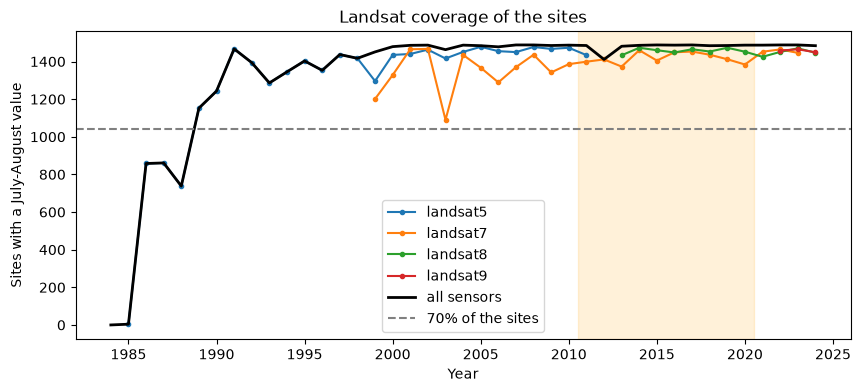

In [6]:
by_sensor = counting.groupby(["year", "sensor"])["gid"].nunique().unstack().reindex(range(1984, 2025))

fig, ax = plt.subplots(figsize=(10, 4))
by_sensor.plot(ax=ax, marker="o", markersize=3)
ax.plot(by_year.index, by_year["sites with a value"], color="black", linewidth=2, label="all sensors")
ax.axhline(LONG_MIN_SITES * len(site_info), color="grey", linestyle="--", label="70% of the sites")
ax.axvspan(MAIN_YEARS[0] - 0.5, MAIN_YEARS[1] + 0.5, color="orange", alpha=0.15)
ax.set_ylabel("Sites with a July-August value")
ax.set_xlabel("Year")
ax.set_title("Landsat coverage of the sites")
ax.legend()
plt.show()

- **The 1980s are thin.** There is nothing in 1984, four sites in 1985, and 50 to 58% of the sites in 1986 to 1988.
- **From 1991 on** at least 86% of the sites have a value every year, and from 2000 on at least 95%.
- **2012 is the thinnest year since 2000,** with 1,411 sites and a median of 2 observations. Landsat 7 was the only sensor that summer.

## The rules for enough data

The design sets three: the long record starts in the first year from which every year has a value at 70% of the sites, a site needs 8 of the 10 years 2011–2020, and over the long record a site needs 80% of the years.

In [7]:
# The rules for enough data
needed = LONG_MIN_SITES * len(site_info)
start = greenness.long_record_start(by_year["sites with a value"], needed)
print(f"Sites needed each year: {needed:.0f} | the long record starts in {start}")

years_with_value = per_site_year.reset_index().groupby("gid")["year"]
in_main = years_with_value.apply(lambda years: years.between(*MAIN_YEARS).sum()).reindex(site_info["gid"], fill_value=0)
print(f"{MAIN_YEARS[0]}-{MAIN_YEARS[1]}: sites with at least {MIN_YEARS} of the 10 years:", (in_main >= MIN_YEARS).sum(),
      "| with all 10:", (in_main == 10).sum(), "| with none:", (in_main == 0).sum())

long_years = 2024 - start + 1
in_long = years_with_value.apply(lambda years: (years >= start).sum()).reindex(site_info["gid"], fill_value=0)
print(f"{start}-2024: {long_years} years | sites with at least {LONG_MIN_YEARS:.0%} of them:",
      (in_long >= LONG_MIN_YEARS * long_years).sum())

Sites needed each year: 1042 | the long record starts in 1989
2011-2020: sites with at least 8 of the 10 years: 1488 | with all 10: 1391 | with none: 0
1989-2024: 36 years | sites with at least 80% of them: 1488


In [8]:
# The same decade seen by one sensor at a time
sensor_rows = []
for sensor, group in counting[counting["year"].between(*MAIN_YEARS)].groupby("sensor"):
    years_per_site = group.groupby("gid")["year"].nunique().reindex(site_info["gid"], fill_value=0)
    sensor_rows.append({"sensor": sensor, "years with scenes": group["year"].nunique(),
                        "observations": len(group),
                        "sites with 8 or more years": (years_per_site >= MIN_YEARS).sum()})
pd.DataFrame(sensor_rows)

,sensor,years with scenes,observations,sites with 8 or more years
0,landsat5,1,4740,0
1,landsat7,10,39635,1468
2,landsat8,8,41202,1280


In [9]:
# What the two stricter checks would leave: 90% of the circle clear, and the 50 m circle
def site_years(observations):
    return greenness.in_season(observations).groupby(["year", "gid"]).size()

small = landsat[landsat["radius_m"] == CHECK_FOOTPRINT_M]
versions = {
    "100 m, at least half clear (the rule)": per_site_year,
    "100 m, at least 90% clear": site_years(main[main["clear_share"] >= CHECK_MIN_CLEAR]),
    "50 m, at least half clear": site_years(small[small["clear_share"] >= MIN_CLEAR]),
}
pd.DataFrame({name: {"site-years with a value": len(counts),
                     f"of them in {MAIN_YEARS[0]}-{MAIN_YEARS[1]}": counts.loc[MAIN_YEARS[0]:MAIN_YEARS[1]].size,
                     "median observations": counts.median()}
              for name, counts in versions.items()}).T

,site-years with a value,of them in 2011-2020,median observations
"100 m, at least half clear (the rule)",54450.0,14782.0,5.0
"100 m, at least 90% clear",54179.0,14701.0,4.0
"50 m, at least half clear",54451.0,14780.0,5.0


## In short

- **The long record starts in 1989,** eleven years before MODIS.
- **Every site has enough data.** All 1,488 sites have at least 8 of the 10 years 2011–2020, and at least 80% of the years from 1989 to 2024.
- **Landsat 7 covers the whole decade** and alone gives 1,468 sites at least 8 years. Landsat 8 covers 2013 to 2020.
- **The stricter checks cost little.** Requiring 90% of the circle to be clear leaves 54,179 of 54,450 site-years, and the 50 m circle leaves as many as the 100 m one.